## Analyzing Trends Across Neighborhoods to Identify Underlying Factors

### Leverage unsupervised learning methods to uncover hidden patterns in the 311 data and compare it with Pittsburgh’s neighborhood data. By analyzing trends across neighborhoods and incorporating additional factors such as demographics, infrastructure, and local conditions, we can identify the root causes of varying closure times and call volumes.



In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import random 

import warnings
warnings.filterwarnings("ignore")

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.model_selection import ParameterGrid
from sklearn.cluster import KMeans

### Clean neighborhood data 

https://data.wprdc.org/dataset/2020-census-redistricting-data-extracts/resource/a8414ed5-c50f-417e-bb67-82b734660da6

In [4]:
# Read in neighborhood data

neighborhoods = pd.read_csv('../Data/2020Census_Neighborhood_Dataset.csv')

In [5]:
#neighborhoods

In [6]:
# Removing columns from 2010 and that are comparisons between 2020 and 2010

to_drop = neighborhoods.columns[neighborhoods.columns.str.startswith(('2010', 'Change'))]
neighborhoods.drop(to_drop, axis=1, inplace=True)

In [7]:
#neighborhoods

In [8]:
# Sanity check = PGH population, per Google, was just under 300k in 2020

neighborhoods['2020_Total_Population'].sum()
# Outputs 302971 - okay

302971

In [9]:
# Changing Neighborhood column capitalization to make merging easier

neighborhoods = neighborhoods.rename(columns = {'Neighborhood': 'neighborhood'})

### Combine neighborhood data with existing DataFrame

Combination in Cleaned Data file, used here for exploration

In [11]:
# Read in existing data

#df = pd.read_csv('../Data/CleanedData_311_Dataset.csv')

In [12]:
# Find which neighborhoods are in existing data

#df['neighborhood'].unique()

In [13]:
# Find if all neighborhoods are present in census data

#a = df['neighborhood'].unique()
#b = neighborhoods['neighborhood'].unique()

#diff = [i for i in a if i not in b]
#diff

In [14]:
# Changes in dataset -> census data

# Central Business District -> Central Business District (Downtown)
# Spring Hill-City View -> 	Spring Hill-City
# Mount Oliver Borough -> Mt. Oliver
# Arlington -> Arlington - Arlington Heights (Combined)
# Arlington Heights -> 	Arlington - Arlington Heights (Combined)

#recode_nbhds = {'Central Business District': 'Central Business District (Downtown)', 'Spring Hill-City View': 'Spring Hill-City',
#                'Mount Oliver Borough': 'Mt. Oliver', 'Arlington': 'Arlington - Arlington Heights (Combined)',
#                'Arlington Heights': 'Arlington - Arlington Heights (Combined)'}

In [15]:
# Making changes to original DataFrame to combine neighborhood data

#df['neighborhood'] = df['neighborhood'].replace(recode_nbhds)

In [16]:
#df['neighborhood'].unique()

In [17]:
# Merging both DataFrams on neighborhood columns

#combineddf = pd.merge(df, neighborhoods, how = 'left', on = 'neighborhood')

In [18]:
#combineddf

### Principal Component Analysis (PCA)

In [20]:
# Changing each neighborhood's race columns to proportions of the neighborhood's population

# Applying to all columns except 'neighborhood' and '2020_Total_Population'
neighborhoods.iloc[:, 2:].astype('float64')
neighborhoods.iloc[:, 3:] = neighborhoods.iloc[:, 3:].div(neighborhoods['2020_Total_Population'], axis=0)

In [21]:
neighborhoods.head()

,_id,neighborhood,2020_Total_Population,2020_OneRace_Population,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population
0,1,Allegheny Center,1419,0.942213,0.481325,0.274841,0.005638,0.165610,0.000705,0.014094,0.057787,0.035236
1,2,Allegheny West,540,0.912963,0.788889,0.059259,0.001852,0.029630,0.001852,0.031481,0.087037,0.075926
2,3,Allentown,2305,0.922343,0.551844,0.340564,0.001302,0.008243,0.002603,0.017787,0.077657,0.035141
3,4,Arlington - Arlington Heights (Combined),2040,0.925980,0.591176,0.303922,0.002451,0.005882,0.000000,0.022549,0.074020,0.033333
4,5,Banksville,4127,0.934335,0.773201,0.047008,0.001696,0.093288,0.000485,0.018658,0.065665,0.038284


In [22]:
# Scaling data for PCA/clustering

nScaled = neighborhoods.copy()
nScaled = nScaled.drop(columns = ['_id', 'neighborhood'])

nScaled[nScaled.columns] = StandardScaler().fit_transform(nScaled)
nScaled.describe()

,2020_Total_Population,2020_OneRace_Population,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population
count,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01,8.900000e+01
mean,1.247442e-17,4.671045e-15,1.811909e-16,2.005262e-16,-4.677906e-17,-4.740278e-17,-1.122697e-17,2.494883e-16,-1.702758e-16,6.689406e-17
std,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00,1.005666e+00
min,-1.031140e+00,-4.373876e+00,-2.136641e+00,-9.990126e-01,-1.288272e+00,-8.238723e-01,-4.250465e-01,-1.642819e+00,-1.895413e+00,-1.392392e+00
25%,-6.896776e-01,-4.111096e-01,-6.408873e-01,-8.387532e-01,-7.806883e-01,-6.456562e-01,-4.250465e-01,-6.119654e-01,-5.640662e-01,-4.904735e-01
50%,-3.168408e-01,8.390247e-02,2.303246e-01,-2.601222e-01,-1.482078e-01,-4.230743e-01,-3.525355e-01,-1.587251e-01,-8.390247e-02,-1.400798e-01
75%,2.201783e-01,5.640662e-01,8.430200e-01,5.480243e-01,6.899168e-01,1.391037e-01,5.813893e-02,2.527526e-01,4.111096e-01,2.642919e-01
max,3.628711e+00,1.895413e+00,1.247668e+00,2.227346e+00,2.838559e+00,3.803626e+00,7.978452e+00,4.164802e+00,4.373876e+00,7.241410e+00


In [23]:
# PCA

pca = PCA(n_components = 2)
pcaResult = pca.fit(nScaled)
pcaResult

PCA(n_components=2)

In [24]:
pcaResult2 = pca.fit_transform(nScaled)

In [25]:
pca.explained_variance_ratio_

array([0.3228708 , 0.21095714])

In [26]:
# Variance explained by the two pcs - 53.38%

sum(pca.explained_variance_ratio_)

0.5338279320527024

In [27]:
pcaViz = pd.DataFrame(abs(pca.components_), columns = nScaled.columns, index = ['PC 1', 'PC 2'])
pcaViz

,2020_Total_Population,2020_OneRace_Population,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population
PC 1,0.116470,0.431616,0.385216,0.439273,0.179906,0.242226,0.142593,0.110799,0.431616,0.385810
PC 2,0.350244,0.382926,0.387036,0.358152,0.339127,0.217129,0.271690,0.192034,0.382926,0.182073


### Elbow Method to Find K-Means Hyperparameters

In [29]:
# Finding inertia of dataset

inertias = []

for k in range(1, 20):
  kmeans = KMeans(n_clusters = k, random_state = 7362)
  kmeans.fit(nScaled)
  inertias.append(kmeans.inertia_)
    
inertias

[890.0,
 697.6853281773961,
 605.2205949172882,
 511.9003865976092,
 429.6436602479686,
 371.1214650569285,
 340.77395095989345,
 315.5539798722913,
 303.5242243946901,
 278.70348821783443,
 251.7319321691608,
 240.44941754377226,
 222.5405312420589,
 208.1177076894582,
 195.33003931759083,
 185.71743602578786,
 179.010744342085,
 170.13430356140282,
 158.90408039080302]

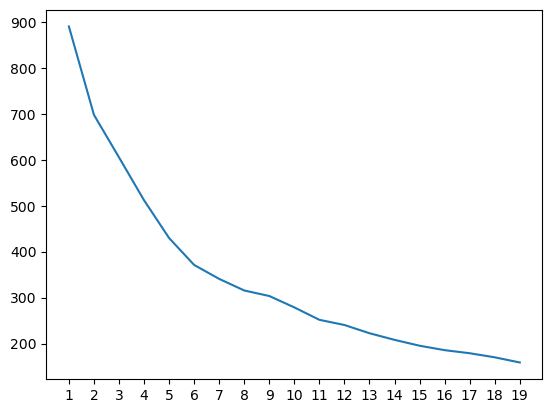

In [30]:
# Plotting elbow graph - 7 clusters

plt.xticks(range(1, 20))
plt.plot(range(1, 20), inertias)

plt.show()

In [31]:
numClusters = 8

### K-Means Clustering

In [33]:
# Getting cluster labels

kmeans = KMeans(n_clusters = numClusters, random_state = 7362)
kmeans_model = kmeans.fit(nScaled)

kmeans_model.labels_

array([4, 5, 1, 1, 4, 0, 5, 5, 4, 0, 1, 1, 4, 0, 4, 4, 1, 1, 4, 0, 2, 1,
       0, 1, 1, 5, 0, 4, 1, 5, 4, 1, 5, 0, 0, 4, 1, 1, 4, 0, 0, 0, 5, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 3, 1, 0, 4, 1, 1, 0, 1, 4, 1, 1, 1,
       7, 5, 4, 1, 4, 1, 1, 1, 7, 7, 1, 1, 4, 1, 1, 0, 1, 0, 1, 6, 3, 4,
       1])

In [72]:
neighborhoods['label'] = kmeans_model.labels_
neighborhoods

,_id,neighborhood,2020_Total_Population,2020_OneRace_Population,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population,labels,label
0,1,Allegheny Center,1419,0.942213,0.481325,0.274841,0.005638,0.165610,0.000705,0.014094,0.057787,0.035236,4,4
1,2,Allegheny West,540,0.912963,0.788889,0.059259,0.001852,0.029630,0.001852,0.031481,0.087037,0.075926,5,5
2,3,Allentown,2305,0.922343,0.551844,0.340564,0.001302,0.008243,0.002603,0.017787,0.077657,0.035141,1,1
3,4,Arlington - Arlington Heights (Combined),2040,0.925980,0.591176,0.303922,0.002451,0.005882,0.000000,0.022549,0.074020,0.033333,1,1
4,5,Banksville,4127,0.934335,0.773201,0.047008,0.001696,0.093288,0.000485,0.018658,0.065665,0.038284,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,85,Upper Lawrenceville,2394,0.946533,0.842941,0.064327,0.002089,0.030911,0.000000,0.006266,0.053467,0.027569,1,1
85,86,West End,205,0.878049,0.575610,0.243902,0.004878,0.029268,0.009756,0.014634,0.121951,0.053659,6,6
86,87,West Oakland,2534,0.968824,0.604578,0.239937,0.002368,0.077743,0.000789,0.043410,0.031176,0.044199,3,3
87,88,Westwood,3332,0.944478,0.659064,0.083433,0.000900,0.177671,0.000600,0.022809,0.055522,0.036615,4,4


In [34]:
# Finding cluster centroids

centroids = kmeans_model.cluster_centers_
centroids

array([[-3.63253019e-01,  8.96088350e-01, -1.53370686e+00,
         1.59828016e+00,  7.16708289e-01, -5.58263274e-01,
        -1.47632260e-01, -2.16293242e-01, -8.96088350e-01,
        -5.33314717e-01],
       [-2.73851378e-01,  7.51664230e-03,  5.58699089e-01,
        -4.05611875e-01, -4.57759202e-01, -4.91078533e-01,
        -4.29815348e-02, -4.49317678e-01, -7.51664230e-03,
        -2.48123528e-01],
       [-1.03114011e+00, -4.37387572e+00,  2.30324573e-01,
        -7.15993441e-01, -1.28827199e+00,  1.21020330e+00,
        -4.25046523e-01, -1.64281881e+00,  4.37387572e+00,
         7.24141047e+00],
       [ 9.77274606e-01,  1.30252358e+00,  2.39454087e-01,
        -5.00056475e-01,  4.01256177e-01,  1.59285517e+00,
        -8.51260004e-02,  2.29898395e+00, -1.30252358e+00,
         3.87656763e-02],
       [ 5.51266246e-01, -7.29126124e-02,  4.23114052e-01,
        -5.95956415e-01, -8.75961728e-02,  1.04555184e+00,
        -1.01885748e-01,  1.23574367e-01,  7.29126124e-02,
         2.

In [35]:
pcaCentroids = pca.transform(centroids)

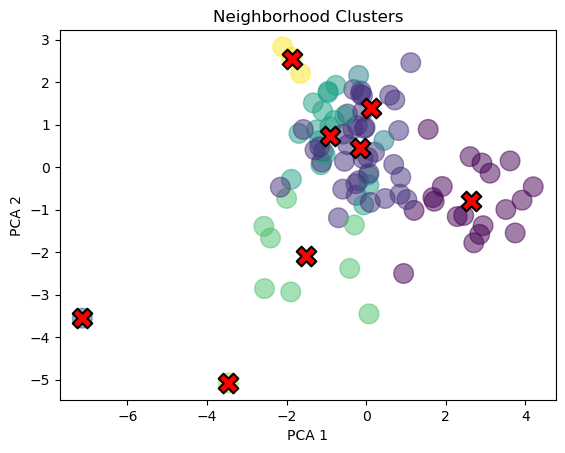

In [36]:
# Visualizing with PCA

plt.scatter(pcaResult2[:, 0], pcaResult2[:, 1], c = kmeans_model.labels_, alpha = 0.5, s = 200)
plt.title('Neighborhood Clusters')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.scatter(pcaCentroids[:, 0], pcaCentroids[:, 1], marker = 'X', s = 200, linewidths = 1.5,
            color = 'red', edgecolors = "black")

plt.show()

In [37]:
# Finding silhouette score: ~0.2246

print("Silhouette_score: ", metrics.silhouette_score(nScaled, kmeans_model.labels_))

Silhouette_score:  0.2245893332537209


In [78]:
nbhoodlist = list(neighborhoods[neighborhoods['label'] == 0]['neighborhood'])
nbhoodlist

['Bedford Dwellings',
 'Bluff',
 'California-Kirkbride',
 'Chartiers City',
 'Crawford-Roberts',
 'East Hills',
 'Garfield',
 'Glen Hazel',
 'Homewood North',
 'Homewood South',
 'Homewood West',
 'Larimer',
 'Lincoln-Lemington-Belmar',
 'Manchester',
 'Middle Hill',
 'Northview Heights',
 'Perry South',
 'Terrace Village',
 'Upper Hill']

In [114]:
# Function to print neighborhoods in each cluster

def clusterAssignment(num):
    '''
    takes cluster number and returns neighborhoods in that cluster

    clusterAssignment(1) -> 'Greenfield, ...'
    '''

    nbhoodlist = list(neighborhoods[neighborhoods['label'] == num]['neighborhood'])

    nbhoodstring = ''

    for n in range(0, len(nbhoodlist) - 1):
        n = str(nbhoodlist[n])
        nbhoodstring = nbhoodstring + n + ', '

    nbhoodstring = nbhoodstring + nbhoodlist[len(nbhoodlist) - 1]

    string = 'The neighborhood(s) in cluster {} are: {}'.format(num, nbhoodstring)

    return string
    

for c in range(0, numClusters):
    print(clusterAssignment(c), '\n')

The neighborhood(s) in cluster 0 are: Bedford Dwellings, Bluff, California-Kirkbride, Chartiers City, Crawford-Roberts, East Hills, Garfield, Glen Hazel, Homewood North, Homewood South, Homewood West, Larimer, Lincoln-Lemington-Belmar, Manchester, Middle Hill, Northview Heights, Perry South, Terrace Village, Upper Hill 

The neighborhood(s) in cluster 1 are: Allentown, Arlington - Arlington Heights (Combined), Bon Air, Brighton Heights, Central Lawrenceville, Central Northside, Crafton Heights, Duquesne Heights, East Allegheny, Elliott, Fineview, Hays, Hazelwood, Lincoln Place, Lower Lawrenceville, Marshall-Shadeland, Morningside, Mount Washington, Mt. Oliver, New Homestead, North Shore, Overbrook, Perry North, Point Breeze, Polish Hill, Regent Square, Ridgemont, South Shore, South Side Slopes, Spring Garden, Spring Hill-City, St. Clair, Stanton Heights, Summer Hill, Swisshelm Park, Troy Hill, Upper Lawrenceville, Windgap 

The neighborhood(s) in cluster 2 are: Chateau 

The neighborho